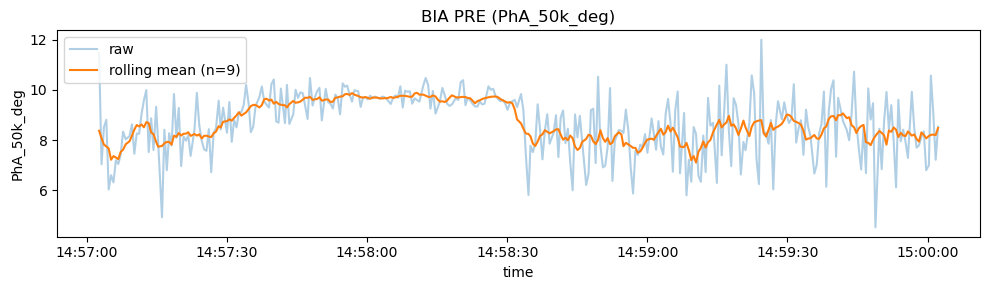

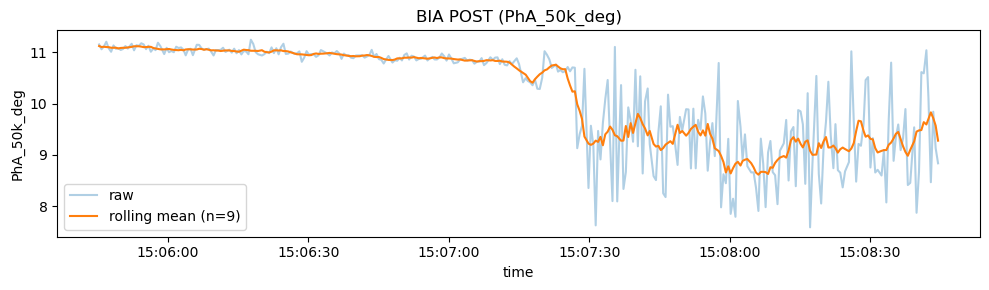


VARIABLES À UTILISER
- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)
- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)
- pha_pre   : numpy array, PhA_50k_deg sur PRE
- pha_post  : numpy array, PhA_50k_deg sur POST
- t_pre     : numpy array, temps (s) relatif au début de PRE
- t_post    : numpy array, temps (s) relatif au début de POST
- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)
- fs_post_est : float, fs approx POST (= 1 / dt_médian)


In [1]:

# BIA RAW IMPORT -> PhA_50k -> PRE/POST WINDOWS -> OUTPUT VARS
# RAW, NO FILTERING / NO RESAMPLING IMPOSED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# CONFIG 

BIA_PKL_PATH = "../data/LEA_BIA_RAW.pkl"   # pkl file exported from BIA device (raw data for pandas)
FREQ_COL = "f_48800"              # ~50 kHz complex impedance column

# Window timestamps (BIA datetime): 3 minutes BEFORE / fatigue inducing protocole / and 3 minutes AFTER
PRE_START_TIME  = "2025-11-28 14:57:02.563"
PRE_END_TIME    = "2025-11-28 15:00:02.563"
POST_START_TIME = "2025-11-28 15:05:45.278"
POST_END_TIME   = "2025-11-28 15:08:44.534"


# LOAD RAW BIA (.pkl)
data_bia_raw = pd.read_pickle(BIA_PKL_PATH)


# ANALYSIS DATAFRAME (same data, cleaner columns)
data_bia = data_bia_raw.copy()

# Parse time
data_bia["time"] = pd.to_datetime(data_bia["timestamp"], errors="coerce")
data_bia = data_bia.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# Complex impedance at ~50 kHz
data_bia["Z_50k"] = data_bia[FREQ_COL].astype(np.complex128)

# Compute R, Xc, PhA (standard convention: Xc = -imag(Z))
data_bia["R_50k_ohm"]   = np.real(data_bia["Z_50k"])
data_bia["Xc_50k_ohm"]  = -np.imag(data_bia["Z_50k"])
data_bia["PhA_50k_deg"] = np.degrees(np.arctan2(data_bia["Xc_50k_ohm"], data_bia["R_50k_ohm"]))

# Compact analysis view
analysis_cols = ["time", "Z_50k", "R_50k_ohm", "Xc_50k_ohm", "PhA_50k_deg", "sat", "min", "max"]
data_bia_analysis = data_bia[analysis_cols].copy()

# CREATE WINDOWS (PRE / POST)

pre_start  = pd.to_datetime(PRE_START_TIME)
pre_end    = pd.to_datetime(PRE_END_TIME)
post_start = pd.to_datetime(POST_START_TIME)
post_end   = pd.to_datetime(POST_END_TIME)

def slice_window(df, t0, t1):
    m = (df["time"] >= t0) & (df["time"] <= t1)  # inclusive bounds [start, end]
    return df.loc[m].copy()

bia_pre  = slice_window(data_bia_analysis, pre_start, pre_end)
bia_post = slice_window(data_bia_analysis, post_start, post_end)


#  PLOTS (just for verification)

def plot_window(df_win, title, y_col="PhA_50k_deg", smooth_n=9):
    if len(df_win) < 5:
        print("Not enough points to plot:", title)
        return
    d = df_win.copy()
    d["time"] = pd.to_datetime(d["time"])
    d = d.sort_values("time")
    y = pd.to_numeric(d[y_col], errors="coerce")
    y_sm = y.rolling(smooth_n, center=True, min_periods=1).mean()

    plt.figure(figsize=(10,3))
    plt.plot(d["time"], y, alpha=0.35, label="raw")
    plt.plot(d["time"], y_sm, label=f"rolling mean (n={smooth_n})")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_window(bia_pre,  "BIA PRE (PhA_50k_deg)")
plot_window(bia_post, "BIA POST (PhA_50k_deg)")


# OUTPUT (variables to use)

pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()

t_pre  = (bia_pre["time"]  - bia_pre["time"].iloc[0]).dt.total_seconds().to_numpy()
t_post = (bia_post["time"] - bia_post["time"].iloc[0]).dt.total_seconds().to_numpy()

dt_pre_med  = float(bia_pre["time"].diff().dt.total_seconds().median())
dt_post_med = float(bia_post["time"].diff().dt.total_seconds().median())
fs_pre_est  = 1.0 / dt_pre_med
fs_post_est = 1.0 / dt_post_med

print("\nVARIABLES À UTILISER")
print("- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)")
print("- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)")
print("- pha_pre   : numpy array, PhA_50k_deg sur PRE")
print("- pha_post  : numpy array, PhA_50k_deg sur POST")
print("- t_pre     : numpy array, temps (s) relatif au début de PRE")
print("- t_post    : numpy array, temps (s) relatif au début de POST")
print("- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)")
print("- fs_post_est : float, fs approx POST (= 1 / dt_médian)")



TAU ESTIMATES (from ACF)
PRE : tau_1e=1 | tau_first_min=3 | chosen_tau=3 lags (~1.539s)
POST: tau_1e=63| tau_first_min=2| chosen_tau=2 lags (~1.026s)


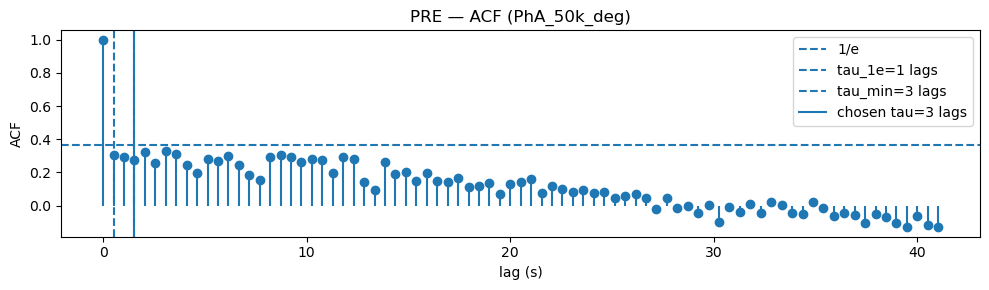

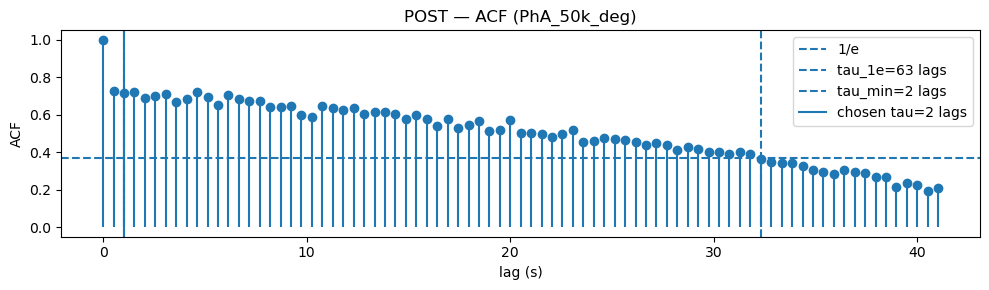

In [ ]:
# ACF + tau (1/e crossing + first local minimum)

from statsmodels.tsa.stattools import acf


# 0) Extract signals (shared reference)

pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()



# 1) Tau estimators from ACF

def estimate_tau_from_acf(x, max_lag=80):
    """
    Returns:
      tau_1e  : first lag where ACF < 1/e (None if never)
      tau_min : first local minimum of ACF (None if none found)
      acf_vals: array ACF[0..max_lag]
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    # safety
    if len(x) < max_lag + 5:
        max_lag = max(10, len(x)//5)

    acf_vals = acf(x, nlags=max_lag, fft=True)
    target = 1 / np.e

    tau_1e = None
    for k in range(1, len(acf_vals)):
        if acf_vals[k] < target:
            tau_1e = k
            break

    tau_min = None
    for k in range(2, len(acf_vals) - 1):
        if acf_vals[k] < acf_vals[k-1] and acf_vals[k] < acf_vals[k+1]:
            tau_min = k
            break

    return tau_1e, tau_min, acf_vals


# 2) Compute ACF + taus

MAX_LAG = 80

tau1e_pre,  tauMin_pre,  acf_pre  = estimate_tau_from_acf(pha_pre,  max_lag=MAX_LAG)
tau1e_post, tauMin_post, acf_post = estimate_tau_from_acf(pha_post, max_lag=MAX_LAG)

# Choose a default tau (prefer local minimum; fallback to 1/e)
tau_pre_lag  = tauMin_pre  if tauMin_pre  is not None else tau1e_pre
tau_post_lag = tauMin_post if tauMin_post is not None else tau1e_post

tau_pre_sec  = None if tau_pre_lag  is None else tau_pre_lag  * dt_pre_med
tau_post_sec = None if tau_post_lag is None else tau_post_lag * dt_post_med

print("TAU ESTIMATES (from ACF)")
print(f"PRE : tau_1e={tau1e_pre} | tau_first_min={tauMin_pre} | chosen_tau={tau_pre_lag} lags (~{tau_pre_sec:.3f}s)")
print(f"POST: tau_1e={tau1e_post}| tau_first_min={tauMin_post}| chosen_tau={tau_post_lag} lags (~{tau_post_sec:.3f}s)")


# 3) Plot ACF (PRE + POST) with tau markers

def plot_acf_with_tau(acf_vals, title, dt_med, tau1e, tauMin, chosen_tau):
    lags = np.arange(len(acf_vals))
    t_lags = lags * dt_med
    target = 1 / np.e

    plt.figure(figsize=(10, 3))
    plt.stem(t_lags, acf_vals, basefmt=" ")
    plt.axhline(target, linestyle="--", label="1/e")

    if tau1e is not None:
        plt.axvline(tau1e * dt_med, linestyle="--", label=f"tau_1e={tau1e} lags")
    if tauMin is not None:
        plt.axvline(tauMin * dt_med, linestyle="--", label=f"tau_min={tauMin} lags")
    if chosen_tau is not None:
        plt.axvline(chosen_tau * dt_med, linestyle="-", label=f"chosen tau={chosen_tau} lags")

    plt.title(title)
    plt.xlabel("lag (s)")
    plt.ylabel("ACF")
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_acf_with_tau(acf_pre,  "PRE — ACF (PhA_50k_deg)",  dt_pre_med,  tau1e_pre,  tauMin_pre,  tau_pre_lag)
plot_acf_with_tau(acf_post, "POST — ACF (PhA_50k_deg)", dt_post_med, tau1e_post, tauMin_post, tau_post_lag)


## Nonlinear Analysis

### Perform phase space reconstruction

The first step to perform phase space reconstruction is to determine optimal time delay. Based on the previous ACF computations, the optimal time delay is 3 for PRE and 2 for POST. 

But other methods to estimate the optimal time delay exists, such a using the first minimum of the mutual information. 



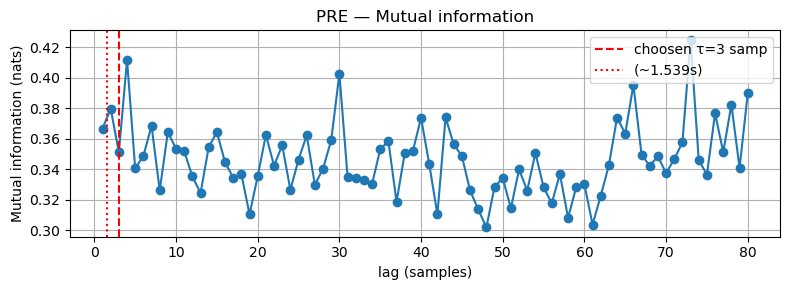

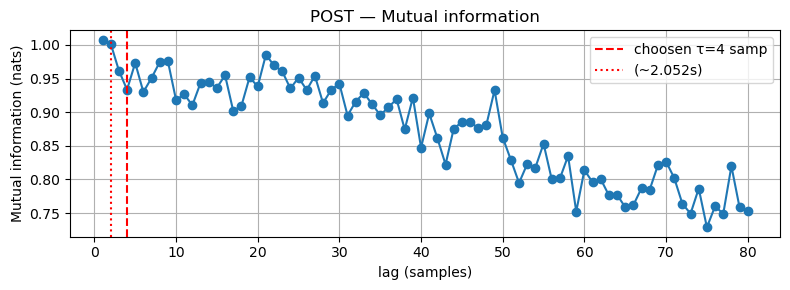

MI-based taus -> PRE: 3 samp (~1.5390000000000001)  |  POST: 4 samp (~2.052)


In [ ]:

# Mutual Information-based tau estimation

def _mutual_information(x, y, bins=32):
    H, _, _ = np.histogram2d(x, y, bins=bins)
    s = H.sum()
    if s == 0:
        return 0.0
    pxy = H / s
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    ix, jy = np.nonzero(pxy)
    mi = np.sum(pxy[ix, jy] * np.log(pxy[ix, jy] / (px[ix] * py[jy])))
    return float(mi)

def compute_mi_lags(x, max_lag=80, bins=32):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.array([]), np.array([])
    max_lag = min(max_lag, max(1, len(x)//2 - 1))
    lags = np.arange(1, max_lag+1)
    mis = [ _mutual_information(x[:-lag], x[lag:], bins=bins) for lag in lags ]
    return lags, np.array(mis)

def first_local_minimum(lags, vals):
    for i in range(1, len(vals)-1):
        if vals[i] < vals[i-1] and vals[i] < vals[i+1]:
            return int(lags[i])
    return None

def plot_mi(lags, mis, chosen_tau=None, dt=None, title="Mutual information vs lag"):
    plt.figure(figsize=(8,3))
    plt.plot(lags, mis, '-o')
    if chosen_tau is not None:
        plt.axvline(chosen_tau, color='red', linestyle='--', label=f'choosen τ={chosen_tau} samp')
        if dt is not None:
            plt.axvline(chosen_tau*dt, color='red', linestyle=':', label=f'(~{chosen_tau*dt:.3f}s)')
    plt.xlabel('lag (samples)')
    plt.ylabel('Mutual information (nats)')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- compute MI-based taus for PRE / POST, prefer MI first local minimum, else keep previous tau_pre_lag/tau_post_lag ---
MAX_LAG = 80
bins_pre  = max(16, int(np.sqrt(len(pha_pre))))  if len(pha_pre)  > 0 else 32
bins_post = max(16, int(np.sqrt(len(pha_post)))) if len(pha_post) > 0 else 32

lags_pre, mi_pre = compute_mi_lags(pha_pre,  max_lag=MAX_LAG, bins=bins_pre)
tau_pre_mi = first_local_minimum(lags_pre, mi_pre) if lags_pre.size else None
plot_mi(lags_pre, mi_pre, chosen_tau=tau_pre_mi, dt=dt_pre_med, title='PRE — Mutual information')

lags_post, mi_post = compute_mi_lags(pha_post, max_lag=MAX_LAG, bins=bins_post)
tau_post_mi = first_local_minimum(lags_post, mi_post) if lags_post.size else None
plot_mi(lags_post, mi_post, chosen_tau=tau_post_mi, dt=dt_post_med, title='POST — Mutual information')

# integrate with existing estimates: prefer MI if found, else keep previously computed tau_pre_lag / tau_post_lag
tau_pre_lag  = int(tau_pre_mi)  if tau_pre_mi  is not None else (tau_pre_lag  if 'tau_pre_lag' in globals()  else None)
tau_post_lag = int(tau_post_mi) if tau_post_mi is not None else (tau_post_lag if 'tau_post_lag' in globals() else None)

tau_pre_sec  = None if tau_pre_lag  is None else tau_pre_lag  * dt_pre_med
tau_post_sec = None if tau_post_lag is None else tau_post_lag * dt_post_med

print(f"MI-based taus -> PRE: {tau_pre_mi} samp (~{tau_pre_sec})  |  POST: {tau_post_mi} samp (~{tau_post_sec})")

The results do not show big differences regarding the estimated tau between ACF first minimum (PRE = 3; POST = 2) and Average Mutual Information first minimum (PRE = 3; POST = 4).

Based on those estimated time delay, I will plot 2D and 3D phase space reconstruction. Because the estimated time delay in the POST condition can be 2 or 4, I will compute both and visually compare them. 

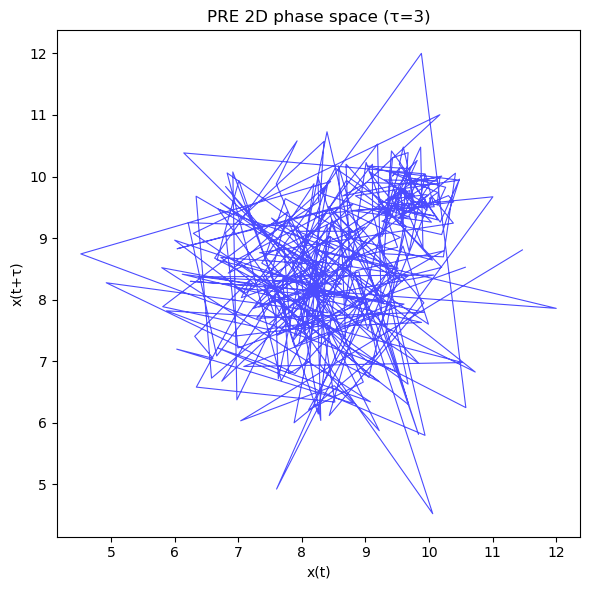

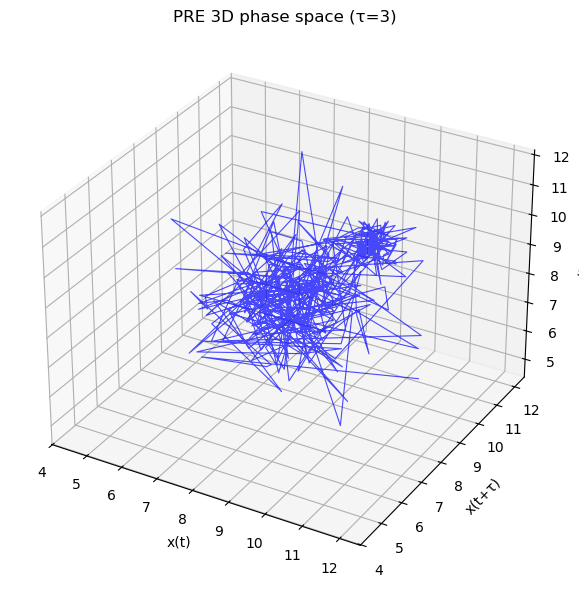

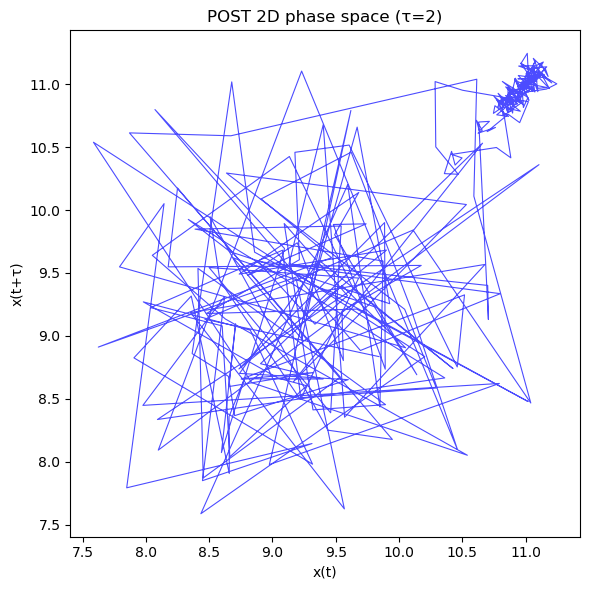

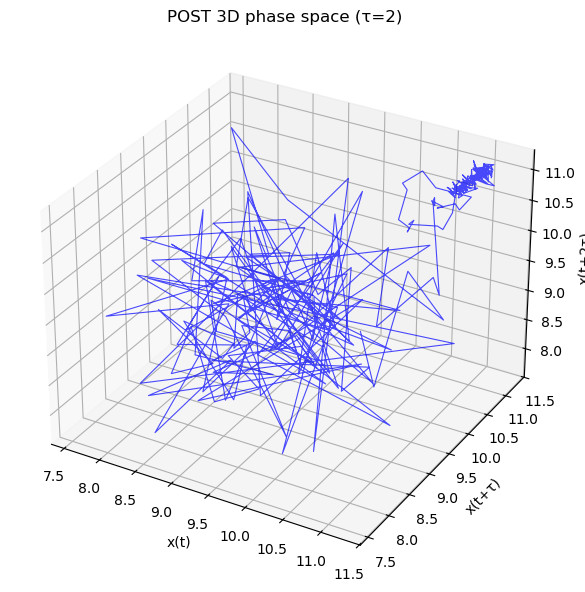

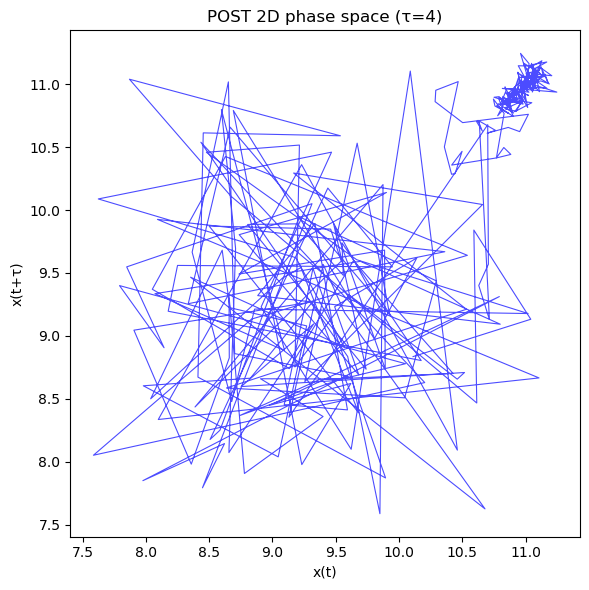

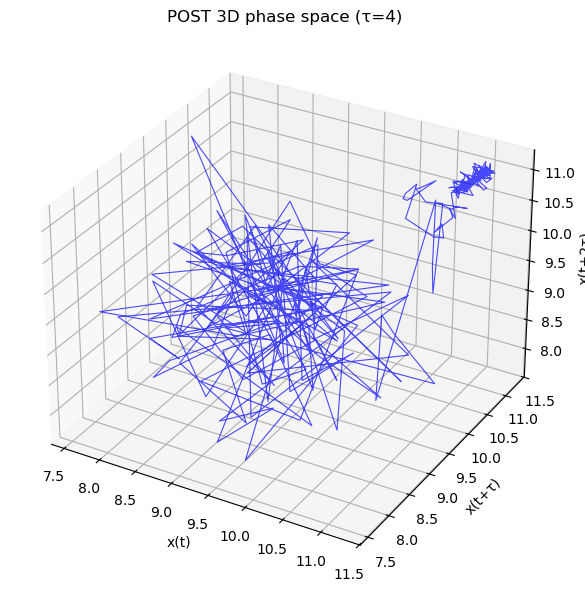

In [59]:

from mpl_toolkits.mplot3d.art3d import Line3DCollection
def embed_time_series(x, d, tau):
    x = np.asarray(x, dtype=float)
    n = x.size - (d - 1) * tau
    if n <= 0:
        raise ValueError("Time series too short")
    return np.array([x[i:i + d * tau:tau] for i in range(n)])

def plot_phase_space(x, tau, name):
    """Plot 2D and 3D phase space for one signal."""
    if x is None or len(x) < 10:
        return

    # 2D
    emb2d = embed_time_series(x, d=2, tau=tau)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(emb2d[:, 0], emb2d[:, 1], 'b-', linewidth=0.8, alpha=0.7)
    ax.set_xlabel('x(t)')
    ax.set_ylabel('x(t+τ)')
    ax.set_title(f'{name} 2D phase space (τ={tau})')
    plt.tight_layout()
    plt.show()

    # 3D
    emb3d = embed_time_series(x, d=3, tau=tau)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(emb3d[:, 0], emb3d[:, 1], emb3d[:, 2], 'b-', linewidth=0.8, alpha=0.7)
    ax.set_xlabel('x(t)')
    ax.set_ylabel('x(t+τ)')
    ax.set_zlabel('x(t+2τ)')
    ax.set_title(f'{name} 3D phase space (τ={tau})')
    plt.tight_layout()
    plt.show()

# Usage:
plot_phase_space(pha_pre, 3, "PRE")
plot_phase_space(pha_post, 2, "POST")
plot_phase_space(pha_post, 4, "POST")


It does not seem that there is much discreapency in the phase space reconstruction weither tau is 2 or 4 for the POST CONDITION. 